In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
df1 = pd.read_csv('/home/senghakrou/stage-1/boamp_renewal_linking_quality/outputs/boamp_bias_report.csv')
df2 = pd.read_csv('/home/senghakrou/stage-1/boamp_renewal_linking_quality/outputs/boamp_linking_stats.csv')
df3 = pd.read_csv('/home/senghakrou/stage-1/boamp_renewal_linking_quality/outputs/boamp_renewal_candidates.csv')
df4 = pd.read_csv('/home/senghakrou/stage-1/boamp_renewal_linking_quality/outputs/boamp_renewal_links.csv')
df5 = pd.read_csv('/home/senghakrou/stage-1/data/processed/boamp_full_flat.csv')

In [3]:
df1.head()

,failure_reason,cpv_div2,n,pct_with_amount,median_duration,pct_duration_imputed,pct_siret_buyer,median_objet_len
0,CPV_MISMATCH,18.0,1,100.0,12.0,0.0,0.0,117.0
1,CPV_MISMATCH,22.0,1,100.0,12.0,0.0,0.0,105.0
2,CPV_MISMATCH,30.0,2,0.0,12.0,0.0,0.0,160.5
3,CPV_MISMATCH,32.0,5,60.0,48.0,20.0,0.0,41.0
4,CPV_MISMATCH,33.0,1,0.0,NaN,100.0,0.0,129.0


In [4]:
df2.head()

,total_ao,right_censored,eligible_ao,linked_events,unlinked,linking_rate_eligible_pct,linking_rate_all_pct,prev_baseline_pct,min_text_threshold,temporal_window_months,default_duration_months
0,1933,833,1100,697,403,63.36,36.06,11.3,0.2,12.0,48.0


In [5]:
df3.head()

,src_idweb,src_buyer_key,src_cpv,src_contract_start,src_duration_months,src_objet,cand_idweb,cand_contract_start,cand_cpv,cand_objet,gap_months,buyer_match_score,cpv_match_score,cpv_used_in_score,text_similarity_score,temporal_proximity_score,composite_score
0,15-31464,NAME:de la mayenne,NaN,2015-03-02,36.0,fourniture de petits materiels d'incendie et d...,17-176560,2017-12-17,35111200.0,Equipements pour Camions Citerne Grande Capaci...,33.54,1.0,NaN,False,0.6922,0.7951,0.7812
1,15-31464,NAME:de la mayenne,NaN,2015-03-02,36.0,fourniture de petits materiels d'incendie et d...,18-154990,2018-11-10,48613000.0,"acquisition, mise en oeuvre et maintenance d'u...",44.32,1.0,NaN,False,0.2740,0.3069,0.4280
2,15-136371,NAME:de la mayenne,NaN,2015-09-07,48.0,marché pour la fourniture des effets d'habille...,18-154990,2018-11-10,48613000.0,"acquisition, mise en oeuvre et maintenance d'u...",38.11,1.0,NaN,False,0.3593,0.1756,0.4384
3,16-183705,NAME:de la mayenne,35111200.0,2016-12-24,12.0,Equipements pour Fourgon Pompe Tonne (FPT) et ...,17-176560,2017-12-17,35111200.0,Equipements pour Camions Citerne Grande Capaci...,11.76,1.0,1.0,True,0.7269,0.9801,0.8868
4,16-183705,NAME:de la mayenne,35111200.0,2016-12-24,12.0,Equipements pour Fourgon Pompe Tonne (FPT) et ...,17-91530,2018-05-29,45212300.0,construction de l'équipement à vocations sport...,17.12,1.0,0.0,True,0.2022,0.5737,0.3456


In [6]:
df3.columns

Index(['src_idweb', 'src_buyer_key', 'src_cpv', 'src_contract_start',
       'src_duration_months', 'src_objet', 'cand_idweb', 'cand_contract_start',
       'cand_cpv', 'cand_objet', 'gap_months', 'buyer_match_score',
       'cpv_match_score', 'cpv_used_in_score', 'text_similarity_score',
       'temporal_proximity_score', 'composite_score'],
      dtype='object')

In [7]:
df4.head()

,contract_id,buyer_key,cpv_div2,category_label,contract_start,declared_duration_months,dur_was_imputed,estimated_end_date,event,renewal_contract_id,...,flag_amount_zero,flag_amount_tiny,flag_amount_ceiling,amount_clean,best_composite_score,second_best_composite_score,score_margin,n_candidates_for_source,single_candidate_match,high_confidence_strict
0,BOAMP:15-30947,NAME:smictom de la vallee de l authion,48.0,Software & Applications,2015-03-02,12.0,False,2016-03-01,0,NaN,...,0,0,0,150000.0,NaN,NaN,NaN,0,False,False
1,BOAMP:15-31464,NAME:de la mayenne,NaN,Unknown,2015-03-02,36.0,False,2018-03-01,1,BOAMP:17-176560,...,0,0,0,NaN,0.7812,0.4280,0.3532,2,False,True
2,BOAMP:15-31513,NAME:reze,38.0,Unknown,2015-03-02,48.0,False,2019-03-02,1,BOAMP:19-87143,...,0,0,0,NaN,0.5101,NaN,NaN,1,True,False
3,BOAMP:15-20937,NAME:nantes,44.0,Unknown,2015-03-03,48.0,False,2019-03-03,1,BOAMP:19-17307,...,0,0,0,NaN,0.8606,0.4720,0.3886,8,False,True
4,BOAMP:15-32168,NAME:des pays de la loire,72.0,IT Services & Consulting,2015-07-21,24.0,False,2017-07-20,1,BOAMP:17-48788,...,0,0,0,NaN,0.5985,0.5695,0.0290,34,False,False


In [8]:
df4.columns

Index(['contract_id', 'buyer_key', 'cpv_div2', 'category_label',
       'contract_start', 'declared_duration_months', 'dur_was_imputed',
       'estimated_end_date', 'event', 'renewal_contract_id',
       'observed_duration_months', 'composite_score', 'text_similarity',
       'cpv_match_score', 'cpv_used_in_score', 'temporal_score',
       'start_date_source', 'link_method', 'type_procedure', 'type_marche',
       'flag_amount_zero', 'flag_amount_tiny', 'flag_amount_ceiling',
       'amount_clean', 'best_composite_score', 'second_best_composite_score',
       'score_margin', 'n_candidates_for_source', 'single_candidate_match',
       'high_confidence_strict'],
      dtype='object')

In [9]:
df5.head()

,idweb,dateparution,datefindiffusion,datelimitereponse,nomacheteur,code_departement,famille,nature,nature_libelle,type_procedure,...,cpv_principal,cpv_all,buyer_siret,buyer_cp,buyer_ville,amount_eur,duration_months,duration_source_field,date_attribution,date_publication_anterieure
0,15-30947,2015-03-02,2015-03-27,2015-03-27T11:30:00+00:00,SMICTOM de la Vallée de l'Authion,49,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,48000000.0,48000000,NaN,49250,Beaufort en vallee,150000.0,12.0,DUREE_MOIS,NaN,NaN
1,15-31464,2015-03-02,2015-04-24,2015-04-24T15:00:00+00:00,Sdis de la Mayenne,53,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,NaN,None|35311400|31121000|34928410|44423200|43830...,NaN,53005,Laval cedex,NaN,36.0,DUREE_MOIS,NaN,NaN
2,15-31513,2015-03-02,2015-04-17,2015-04-17T11:00:00+00:00,Ville de Rezé,44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,38720000.0,38720000|31224500|48620000,NaN,44403,Rezé Cedex,NaN,48.0,DUREE_MOIS,NaN,NaN
3,15-20937,2015-03-03,2015-04-14,2015-04-14T11:00:00+00:00,Ville de Nantes,44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,44512000.0,44512000|None|31000000|44810000|31500000|44522...,NaN,44000,nantes,NaN,48.0,DUREE_MOIS,NaN,NaN
4,15-31397,2015-03-03,2015-04-01,NaN,SDIS de la Sarthe,72,JOUE,ATTRIBUTION,Résultat de marché,NEGOCIE,...,48814300.0,48814300,NaN,72190,COULAINES,NaN,NaN,NaN,2015-02-17,NaN


In [10]:
df = pd.read_csv('/home/senghakrou/stage-1/data/processed/boamp_phase2_survival.csv')
df.head()

,contract_id,source,buyer_key,cpv_div2,category_label,start_date,declared_duration_months,event,observed_duration_months,censoring_duration_months,...,temporal_score,flag_amount_zero,flag_amount_tiny,flag_amount_ceiling,best_composite_score,second_best_composite_score,score_margin,n_candidates_for_source,single_candidate_match,high_confidence_strict
0,BOAMP:15-30947,BOAMP,NAME:smictom de la vallee de l authion,48.0,Software & Applications,2015-03-02,12.0,0,118.00,118.0,...,NaN,0,0,0,NaN,NaN,NaN,0,False,False
1,BOAMP:15-31464,BOAMP,NAME:de la mayenne,NaN,Unknown,2015-03-02,36.0,1,33.54,NaN,...,0.7951,0,0,0,0.7812,0.4280,0.3532,2,False,True
2,BOAMP:15-31513,BOAMP,NAME:reze,38.0,Unknown,2015-03-02,48.0,1,51.12,NaN,...,0.7403,0,0,0,0.5101,NaN,NaN,1,True,False
3,BOAMP:15-20937,BOAMP,NAME:nantes,44.0,Unknown,2015-03-03,48.0,1,47.17,NaN,...,0.9312,0,0,0,0.8606,0.4720,0.3886,8,False,True
4,BOAMP:15-32168,BOAMP,NAME:des pays de la loire,72.0,IT Services & Consulting,2015-07-21,24.0,1,24.11,NaN,...,0.9906,0,0,0,0.5985,0.5695,0.0290,34,False,False


## Phase 1 report figures

This notebook is the source of the academic BOAMP figures used by `reports/phase1_technical_report.tex`.
Running the final code cell regenerates the seven PDF figures in `reports/figures/`.


In [11]:
# ── Academic figure style (consistent across all project notebooks) ────────
try:
    import matplotlib.pyplot as _plt
    _plt.style.use("seaborn-v0_8-paper")
except OSError:
    pass

# Phase 1 report figures - setup
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "boamp_renewal_linking_quality").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / "boamp_renewal_linking_quality" / "outputs"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAVE_KW = {"format": "png", "bbox_inches": "tight", "pad_inches": 0.12, "dpi": 300}

COLORS = {
    "navy": "#12355B",
    "blue": "#2A6F97",
    "light_blue": "#9CC5D5",
    "teal": "#3C8D8A",
    "orange": "#D17B0F",
    "red": "#B24C63",
    "green": "#5B8A3C",
    "gray": "#6C757D",
    "light_gray": "#D9DEE2",
    "grid": "#E9ECEF",
}

sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "legend.frameon": True,
        "legend.framealpha": 0.85,
    },
)


def finalize_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color=COLORS["grid"], linewidth=0.8)
    ax.grid(axis="x" if grid_axis == "y" else "y", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


In [12]:
from IPython.display import display

# Phase 1 report figures - generation functions
def load_phase1_figure_data():
    handoff = pd.read_csv(PROCESSED_DIR / "boamp_phase2_survival.csv")
    boamp = pd.read_csv(PROCESSED_DIR / "boamp_full_clean.csv")
    cands = pd.read_csv(OUTPUTS_DIR / "boamp_renewal_candidates.csv")

    handoff["start_date"] = pd.to_datetime(handoff["start_date"], errors="coerce")
    handoff["dur_was_imputed"] = handoff["dur_was_imputed"].astype(str).str.lower().eq("true")

    numeric_cols = [
        "declared_duration_months",
        "observed_duration_months",
        "renewal_duration_months",
        "censoring_duration_months",
        "composite_score",
        "text_similarity",
        "cpv_match_score",
        "temporal_score",
    ]
    for col in numeric_cols:
        if col in handoff.columns:
            handoff[col] = pd.to_numeric(handoff[col], errors="coerce")

    cands["composite_score"] = pd.to_numeric(cands["composite_score"], errors="coerce")
    linked = handoff[handoff["event"] == 1].copy()
    return handoff, cands, boamp, linked


def save_duration_distribution(boamp):
    ao = boamp[boamp["nature"] == "APPEL_OFFRE"].copy()
    durations = pd.to_numeric(ao["duration_clean"], errors="coerce").dropna()
    # Curated administrative buckets (matches Table 6 in the report): exact-value counts
    # for the round/ceiling durations, with everything else (incl. spurious non-round
    # clusters such as ~3.94 mo) folded into "Other". Using raw value_counts().head(8)
    # would surface those artefacts and drop the 72-month ceiling.
    named = [48, 12, 24, 36, 60, 4, 6, 72]
    bucket = {value: int((durations == value).sum()) for value in named}
    other = int(len(durations) - sum(bucket.values()))
    labels = [str(value) for value in named]
    values = [bucket[value] for value in named]
    colors = [COLORS["navy"] if value in {12, 24, 36, 48} else COLORS["blue"] for value in named]
    if other > 0:
        labels.append("Other")
        values.append(other)
        colors.append(COLORS["light_gray"])

    total = len(durations)
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ypos = np.arange(len(labels))
    bars = ax.barh(ypos, values, color=colors, edgecolor="white", linewidth=0.8)
    for bar, value in zip(bars, values):
        ax.text(bar.get_width() + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, f"{value} ({value / total:.1%})", va="center", ha="left", fontsize=9)

    ax.set_yticks(ypos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("APPEL_OFFRE notices")
    ax.set_ylabel("Declared duration (months)")
    ax.set_title("Declared BOAMP durations are concentrated on round administrative values", loc="left")
    ax.text(0.01, -0.18, f"Valid AO durations: n = {total:,}. The four round values 12/24/36/48 months account for {(durations.isin([12, 24, 36, 48]).mean()):.1%}.", transform=ax.transAxes, fontsize=9, color=COLORS["gray"])
    finalize_ax(ax)
    output = REPORT_FIGURES_DIR / "fig_duration_dist.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def save_score_distributions(linked):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
    metrics = [
        ("composite_score", "Composite score", COLORS["navy"], 0.50, 0.70),
        ("text_similarity", "Semantic text similarity", COLORS["blue"], 0.20, None),
    ]
    bins = np.linspace(0.18, 1.0, 18)

    for ax, (col, title, color, ref1, ref2) in zip(axes, metrics):
        series = linked[col].dropna()
        sns.histplot(series, bins=bins, stat="count", color=color, alpha=0.85, edgecolor="white", linewidth=0.6, ax=ax)
        sns.kdeplot(series, color=COLORS["gray"], linewidth=1.6, ax=ax, clip=(0, 1))
        ax.axvline(series.mean(), color=COLORS["orange"], linestyle="--", linewidth=1.4)
        ax.axvline(ref1, color=COLORS["red"], linestyle=":", linewidth=1.3)
        if ref2 is not None:
            ax.axvline(ref2, color=COLORS["green"], linestyle=":", linewidth=1.3)
        ax.set_xlim(0.18, 1.0)
        ax.set_xlabel(title)
        ax.set_title(title, loc="left")
        ax.text(0.98, 0.95, f"mean = {series.mean():.3f}\nmedian = {series.median():.3f}", transform=ax.transAxes, ha="right", va="top", fontsize=9, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": COLORS["light_gray"]})
        finalize_ax(ax)

    axes[0].set_ylabel("Linked contracts")
    fig.suptitle("Match-quality distributions among linked BOAMP renewals", x=0.07, ha="left", fontsize=12)
    fig.tight_layout()
    output = REPORT_FIGURES_DIR / "fig_score_distributions.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def save_temporal_error(linked):
    data = linked.copy()
    data["duration_error"] = data["renewal_duration_months"] - data["declared_duration_months"]
    fig, axes = plt.subplots(2, 1, figsize=(8.8, 6.6), sharex=True, height_ratios=[2.2, 1.2])
    groups = [(False, "Observed declared duration", COLORS["navy"]), (True, "Duration imputed to 48 months", COLORS["orange"])]

    for is_imputed, label, color in groups:
        subset = data[data["dur_was_imputed"] == is_imputed]["duration_error"].dropna()
        sns.histplot(subset, bins=np.arange(-12.5, 13.5, 1), color=color, alpha=0.72, edgecolor="white", linewidth=0.5, ax=axes[0], label=f"{label} (n={len(subset):,})")

    axes[0].axvline(0, color="black", linewidth=1.0)
    axes[0].set_ylabel("Linked contracts")
    axes[0].set_title("Observed renewal gap minus declared duration", loc="left")
    axes[0].legend(frameon=False, loc="upper left")
    axes[0].text(0.98, 0.95, f"mean error = {data['duration_error'].mean():.2f} months\nmean |error| = {data['duration_error'].abs().mean():.2f} months", transform=axes[0].transAxes, ha="right", va="top", fontsize=9, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": COLORS["light_gray"]})
    finalize_ax(axes[0])

    summary = pd.DataFrame({"Group": [label for _, label, _ in groups], "Mean |error|": [data[data["dur_was_imputed"] == is_imputed]["duration_error"].abs().mean() for is_imputed, _, _ in groups]})
    axes[1].barh(summary["Group"], summary["Mean |error|"], color=[COLORS["navy"], COLORS["orange"]], edgecolor="white", linewidth=0.8)
    for idx, value in enumerate(summary["Mean |error|"]):
        axes[1].text(value + 0.1, idx, f"{value:.1f} mo", va="center", fontsize=9)
    axes[1].set_xlabel("Mean absolute error (months)")
    axes[1].set_ylabel("")
    axes[1].set_title("Average error is larger when duration must be imputed", loc="left")
    finalize_ax(axes[1])
    fig.tight_layout()
    output = REPORT_FIGURES_DIR / "fig_temporal_error.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def save_linking_by_year(handoff):
    by_year = handoff.assign(year=handoff["start_date"].dt.year).groupby("year", as_index=False).agg(total=("contract_id", "count"), linked=("event", "sum"))
    by_year["unlinked"] = by_year["total"] - by_year["linked"]
    by_year["rate"] = 100 * by_year["linked"] / by_year["total"]
    fig, axes = plt.subplots(2, 1, figsize=(9.2, 6.8), sharex=True, height_ratios=[2.0, 1.3])
    x = np.arange(len(by_year))

    axes[0].bar(x, by_year["linked"], color=COLORS["navy"], edgecolor="white", linewidth=0.7, label="Linked")
    axes[0].bar(x, by_year["unlinked"], bottom=by_year["linked"], color=COLORS["light_blue"], edgecolor="white", linewidth=0.7, label="Censored")
    axes[0].set_ylabel("Eligible contracts")
    axes[0].set_title("Eligible BOAMP contracts by start year", loc="left")
    axes[0].legend(frameon=False, ncol=2, loc="upper left")
    finalize_ax(axes[0])

    axes[1].plot(x, by_year["rate"], color=COLORS["orange"], marker="o", linewidth=2.0)
    for xi, value in zip(x, by_year["rate"]):
        axes[1].text(xi, value + 1.2, f"{value:.0f}%", ha="center", fontsize=8.8, color=COLORS["orange"])
    axes[1].set_ylabel("Linking rate")
    axes[1].set_xlabel("Contract start year")
    axes[1].set_ylim(0, max(100, by_year["rate"].max() + 8))
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(by_year["year"].astype(int).astype(str))
    axes[1].set_title("Linking rate falls in recent cohorts because of right-censoring", loc="left")
    finalize_ax(axes[1])
    fig.tight_layout()
    output = REPORT_FIGURES_DIR / "fig_linking_by_year.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def save_threshold_sensitivity(handoff, linked):
    thresholds = np.arange(0.20, 0.55, 0.05)
    retained = [(linked["text_similarity"] >= threshold).sum() for threshold in thresholds]
    rates = [100 * count / len(handoff) for count in retained]
    fig, axes = plt.subplots(2, 1, figsize=(8.8, 6.4), sharex=True, height_ratios=[1.6, 1.2])
    x = np.arange(len(thresholds))
    labels = [f"{value:.2f}" for value in thresholds]

    axes[0].plot(x, retained, color=COLORS["navy"], marker="o", linewidth=2.0)
    axes[0].fill_between(x, retained, color=COLORS["light_blue"], alpha=0.35)
    axes[0].set_ylabel("Linked events retained")
    axes[0].set_title("Sensitivity to the text-similarity threshold", loc="left")
    finalize_ax(axes[0])

    axes[1].plot(x, rates, color=COLORS["orange"], marker="o", linewidth=2.0)
    axes[1].fill_between(x, rates, color="#F7D9B1", alpha=0.4)
    axes[1].set_ylabel("Eligible linking rate")
    axes[1].set_xlabel("Minimum text-similarity threshold")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].axvline(0, color=COLORS["red"], linestyle=":", linewidth=1.2)
    finalize_ax(axes[1])
    fig.tight_layout()
    output = REPORT_FIGURES_DIR / "fig_threshold_sensitivity.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def save_confidence_tiers(handoff, linked):
    composite = linked["composite_score"].dropna()
    tiers = pd.DataFrame({"label": ["High confidence", "Medium confidence", "Low confidence", "Censored"], "count": [int((composite >= 0.70).sum()), int(((composite >= 0.50) & (composite < 0.70)).sum()), int((composite < 0.50).sum()), int((handoff["event"] == 0).sum())], "color": [COLORS["green"], COLORS["orange"], COLORS["red"], COLORS["light_blue"]]})
    tiers["share"] = 100 * tiers["count"] / tiers["count"].sum()
    fig, ax = plt.subplots(figsize=(9.2, 3.8))
    left = 0.0
    for _, row in tiers.iterrows():
        ax.barh([0], [row["count"]], left=left, color=row["color"], edgecolor="white", linewidth=1.0, height=0.56)
        center = left + row["count"] / 2
        ax.text(center, 0, f"{row['label']}\n{row['count']} ({row['share']:.1f}%)", ha="center", va="center", fontsize=9.4)
        left += row["count"]

    ax.set_xlim(0, tiers["count"].sum())
    ax.set_yticks([])
    ax.set_xlabel(f"Eligible BOAMP contracts (n = {tiers['count'].sum():,})")
    ax.set_title("Confidence profile of the BOAMP-only handoff", loc="left")
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    fig.tight_layout()
    output = REPORT_FIGURES_DIR / "fig_confidence_tiers.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def save_score_margin(cands):
    margins = []
    for _, scores in cands.groupby("src_idweb")["composite_score"]:
        ordered = scores.dropna().sort_values(ascending=False).head(2).to_numpy()
        if len(ordered) == 2:
            margins.append(float(ordered[0] - ordered[1]))
    margins_arr = np.array(margins)

    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    sns.histplot(margins_arr, bins=np.arange(0, 0.55, 0.025), color=COLORS["blue"], alpha=0.85, edgecolor="white", linewidth=0.6, ax=ax)
    ax.axvline(0.05, color=COLORS["red"], linestyle=":", linewidth=1.4)
    ax.axvline(0.10, color=COLORS["green"], linestyle="--", linewidth=1.4)
    ax.set_xlabel("Composite-score margin: best candidate minus second-best candidate")
    ax.set_ylabel("Source contracts")
    ax.set_title("Candidate separation is usually clear, but a minority remain ambiguous", loc="left")
    ax.text(0.98, 0.95, f"n = {len(margins_arr):,}\nmean margin = {margins_arr.mean():.3f}\nmargin < 0.05: {(margins_arr < 0.05).sum()} ({(margins_arr < 0.05).mean():.1%})", transform=ax.transAxes, ha="right", va="top", fontsize=9, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": COLORS["light_gray"]})
    finalize_ax(ax)
    output = REPORT_FIGURES_DIR / "fig_score_margin.png"
    display(fig)
    fig.savefig(output, **SAVE_KW)
    plt.close("all")
    return output


def generate_phase1_report_figures():
    handoff, cands, boamp, linked = load_phase1_figure_data()
    generated = [save_duration_distribution(boamp), save_score_distributions(linked), save_temporal_error(linked), save_linking_by_year(handoff), save_threshold_sensitivity(handoff, linked), save_confidence_tiers(handoff, linked), save_score_margin(cands)]
    return generated


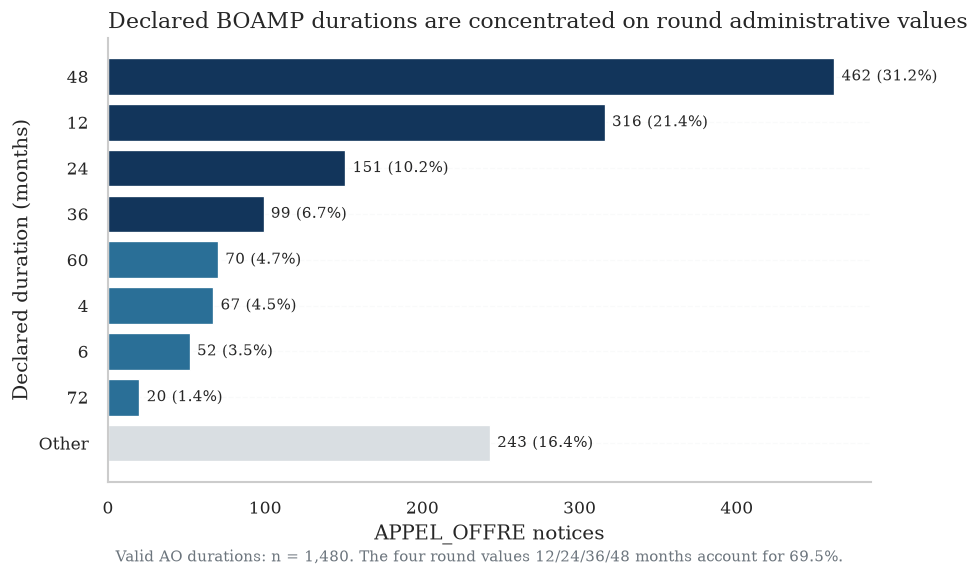

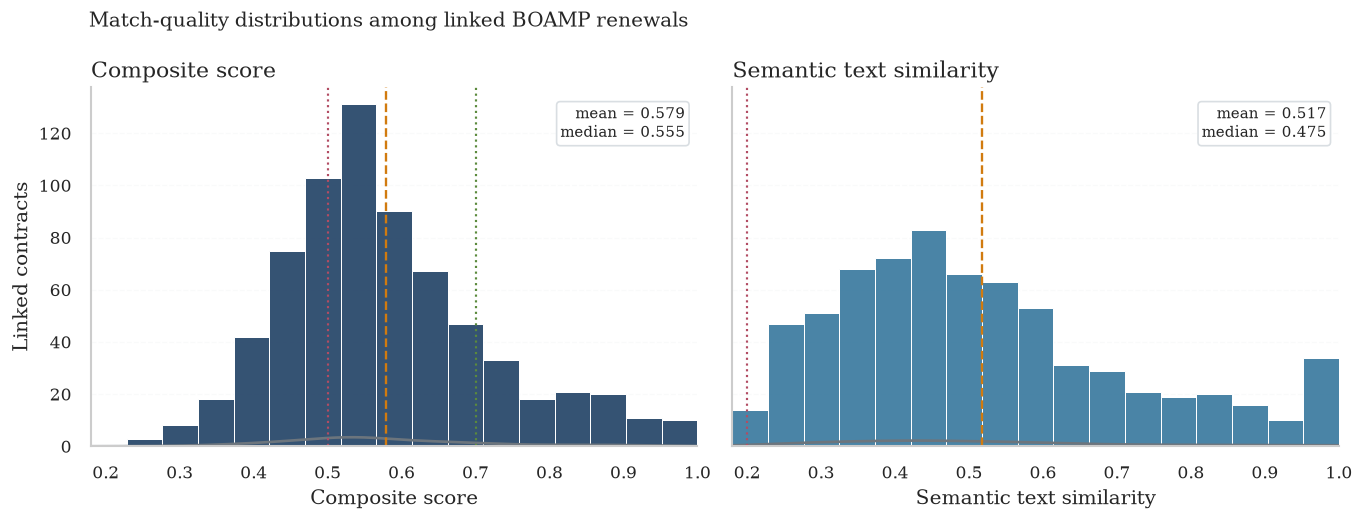

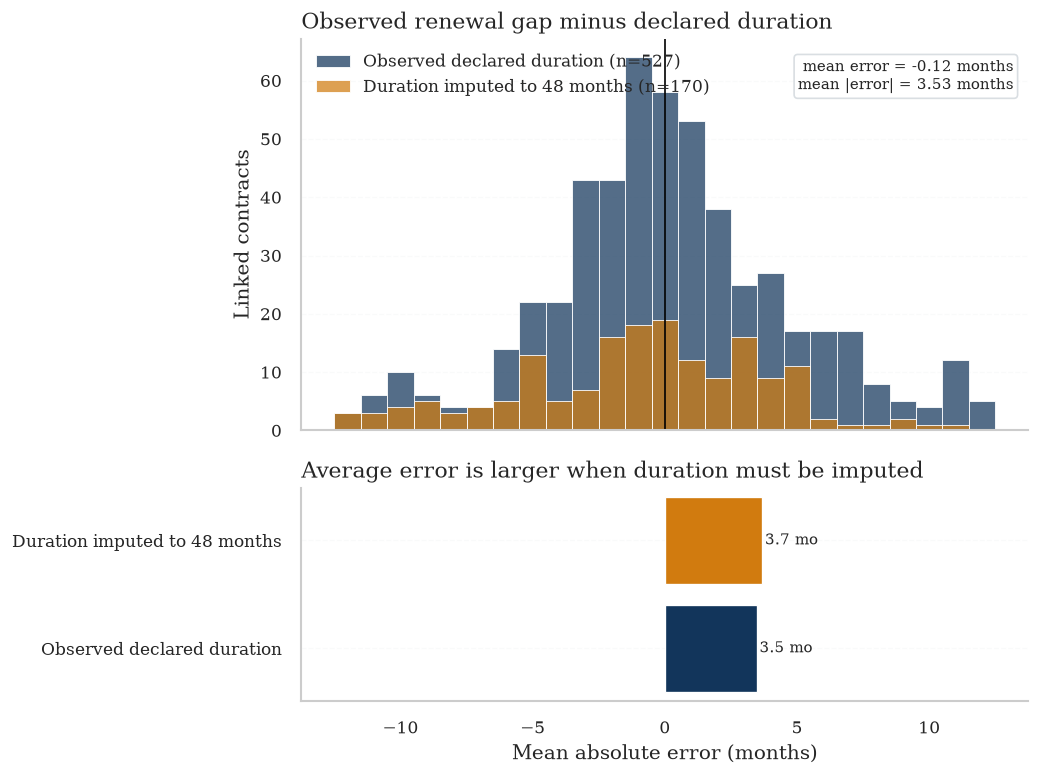

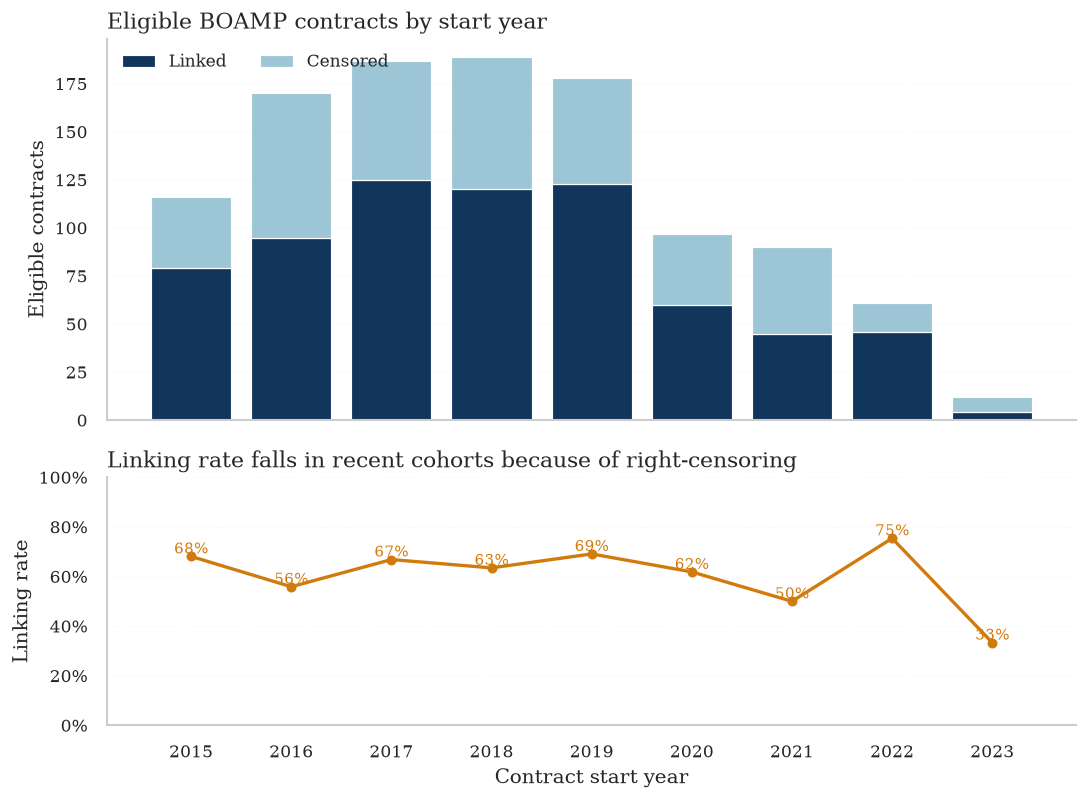

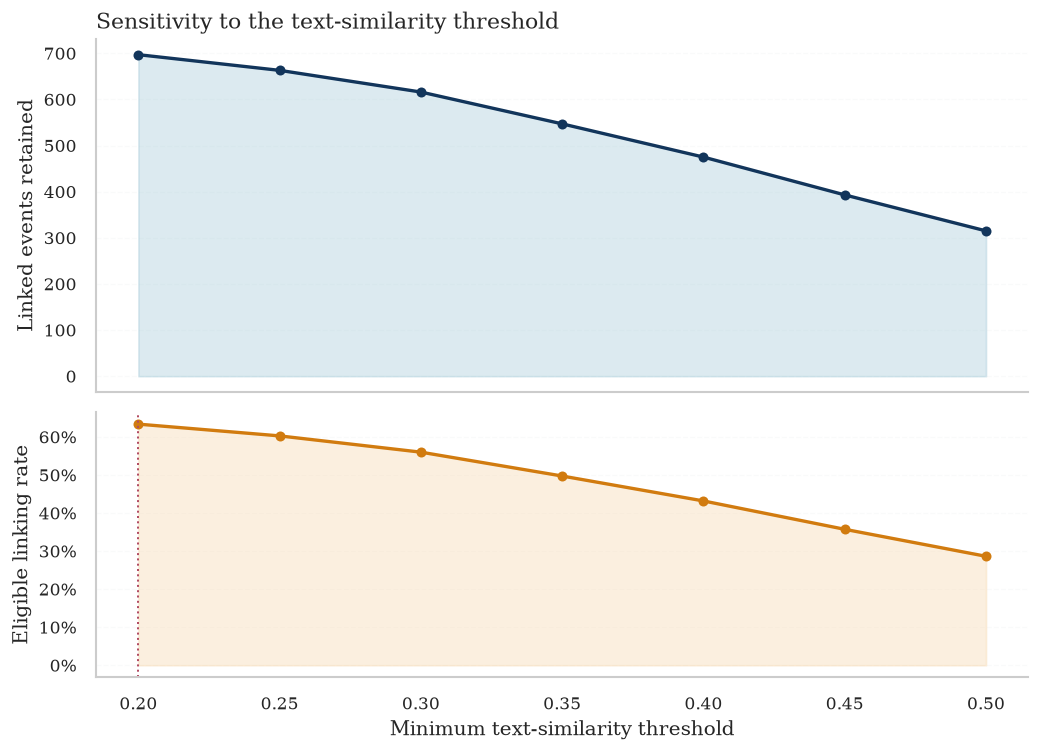

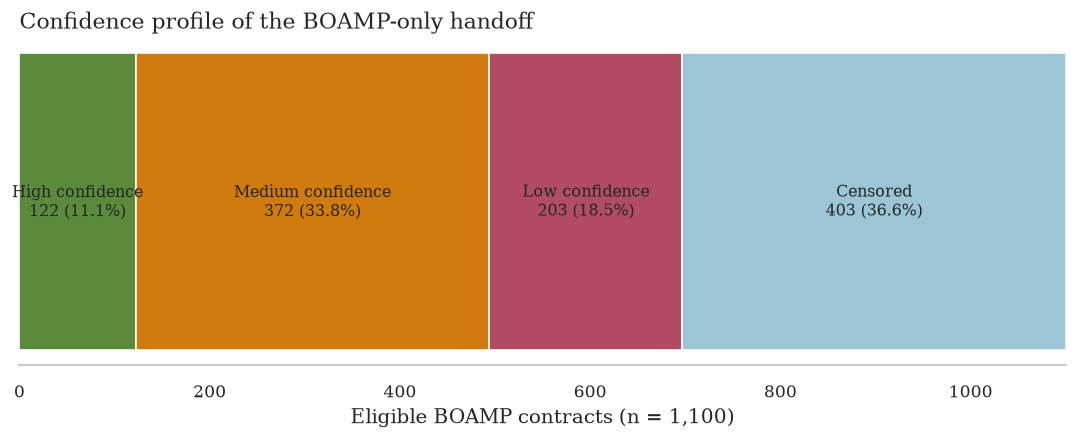

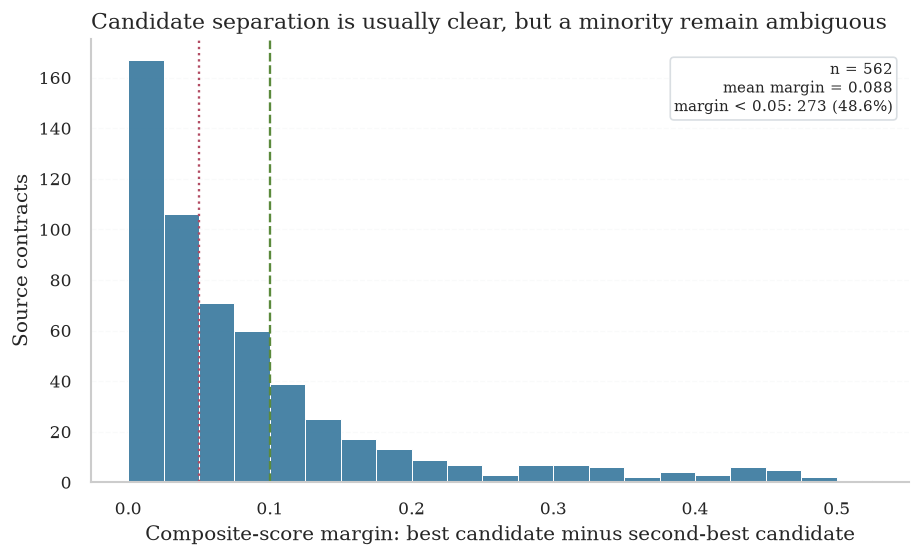

[PosixPath('reports/figures/fig_duration_dist.png'),
 PosixPath('reports/figures/fig_score_distributions.png'),
 PosixPath('reports/figures/fig_temporal_error.png'),
 PosixPath('reports/figures/fig_linking_by_year.png'),
 PosixPath('reports/figures/fig_threshold_sensitivity.png'),
 PosixPath('reports/figures/fig_confidence_tiers.png'),
 PosixPath('reports/figures/fig_score_margin.png')]

In [13]:
# Phase 1 report figures - run this cell to refresh all report PDFs
generated_figures = generate_phase1_report_figures()
[p.relative_to(PROJECT_ROOT) for p in generated_figures]
